# PREVISAO DE RISCO DE CREDITO COM MACHINE LEARNING 

##### Este projeto tem como objetivo resolver um problema real enfrentado por um banco alemão: clientes que recebem empréstimos, mas nem todos conseguem devolver o valor emprestado, gerando risco de inadimplência para a instituição.

##### Utilizando uma base histórica de clientes classificados como bons ou maus pagadores, o projeto busca construir modelos de Machine Learning Supervisionado capazes de prever se um novo cliente será apto a receber crédito, ajudando o banco a tomar decisões mais embasadas e reduzir perdas financeiras.

irei seguir a seguinte pipiline 
1. definir o problema da empresa
2. coletar a base de dados e ter uma visao geral
3. separar em duas base - (treino/teste)
4. EDA
5. tratamento de dados
6. treinamento dos modelos, e comparação e tuning
7. produto final e priorização
8. conclusões

Nesse notebook irei fazer as etapas de 5-8,objetivo principal aqui é construir um modelo preditivo, sendo o recall a métrica de interesse. Com este modelo, o banco poderá tomar decisões informadas que equilibram a geração de lucros com uma gestão prudente de riscos, beneficiando tanto a empresa quanto seus clientes. Além disso, abordarei essas etapas em mais detalhes abaixo, apresentando uma visão geral e a explicação dos motivos para cada decisão tomada.

In [1]:
#importando as bibliotecas necessarias
!pip install xgboost
!pip install category-encoders

import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    cross_val_predict, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from modelagem_utils import (
    evaluate_models_cv,
    importancia_por_variavel_original,
    plotar_importancia_variaveis
)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1

[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1


[notice] To update, run: python.exe -m pip install --upgrade pip

A base de dados foi obtida do UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data


In [2]:
# carregar base de dados e renomear as colunas com base na descriçao da base
df = pd.read_csv('german.data', sep=' ', header=None)
nomes_colunas = [
    'checking_account',
    'duration_months',
    'credit_history',
    'purpose',
    'credit_amount',
    'savings_account',
    'employment_since',
    'installment_rate',
    'personal_status_sex',
    'other_debtors',
    'residence_since',
    'property',
    'age',
    'other_installment_plans',
    'housing',
    'existing_credits',
    'job',
    'dependents',
    'telephone',
    'foreign_worker',
    'credit_risk'
]
df.columns = nomes_colunas
# Mapeamento explícito: 1 (Bom Pagador) -> 0 | 2 (Mau Pagador) -> 1
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

# Converte para inteiro (garante o tipo de dado correto)
df['credit_risk'] = df['credit_risk'].astype(int)

df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## Separar a base em duas partes, teste e treino

In [3]:
#separar base de treino e de teste mantendo a proporcao da variavel target
X = df.drop(columns='credit_risk')  
y = df['credit_risk']               

# Fazer o split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    stratify=y,        
    random_state=42
)


In [4]:
print(f'base de features treino tem a forma: {X_train.shape}.')
print(f'base de objetivo treino tem a forma: {y_train.shape}.')
print(f'base de features teste tem a forma: {X_test.shape}.')
print(f'base de objetivo teste tem a forma: {y_test.shape}.')

base de features treino tem a forma: (800, 20).
base de objetivo treino tem a forma: (800,).
base de features teste tem a forma: (200, 20).
base de objetivo teste tem a forma: (200,).


In [5]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


podemos notar que a proporcao nas duas bases teste e treino estao iguais

In [6]:
treino = pd.concat([X_train , y_train],axis = 1)

In [7]:
features_numericas = X_train.select_dtypes('number').columns.tolist()
features_categoricas = X_train.select_dtypes('object').columns.tolist()
print(f'há {len(features_numericas)} features numericas')
print(features_numericas)
print(f'há {len(features_categoricas)} features categoricas')
print(features_categoricas)



há 7 features numericas
['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents']
há 13 features categoricas
['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


Vou analisar os valores únicos das variáveis categóricas. A cardinalidade é um fator importante na escolha de uma técnica de codificação (encoding) para essas variáveis.


In [8]:
for i in features_categoricas:

    print(i)
    print('~'*40)
    print(f'ha {treino[i].nunique()} valores na coluna {i}')
    print(treino[i].value_counts(normalize = True))
    print()
    print()

checking_account
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 4 valores na coluna checking_account
checking_account
A14    0.39500
A11    0.27375
A12    0.26750
A13    0.06375
Name: proportion, dtype: float64


credit_history
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 5 valores na coluna credit_history
credit_history
A32    0.52000
A34    0.30000
A33    0.09000
A31    0.05125
A30    0.03875
Name: proportion, dtype: float64


purpose
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 10 valores na coluna purpose
purpose
A43     0.26875
A40     0.24250
A42     0.18625
A41     0.10500
A49     0.09875
A46     0.05000
A45     0.02250
A44     0.01250
A410    0.00750
A48     0.00625
Name: proportion, dtype: float64


savings_account
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 5 valores na coluna savings_account
savings_account
A61    0.59375
A65    0.18000
A62    0.11250
A63    0.06250
A64    0.05125
Name: proportion, dtype: float64


employment_since
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ha 5 va

INSIGHTS

    - Analisando os valores únicos das variáveis categóricas, algumas colunas (como employment_since, job, checking_account e savings_account) pareciam ter uma ordem natural à primeira vista. Essa hipótese será verificada mais adiante, cruzando cada categoria com a proporção de risco (credit_risk), antes de decidir a técnica de encoding mais adequada para cada uma.
    
    - Para as colunas sem ordem natural, pode ser interessante separar em duas abordagens: colunas com poucas categorias, como personal_status_sex, other_debtors e housing, podem usar one-hot encoding sem gerar muitas colunas novas.

    - Colunas com mais categorias, como purpose , podem ser tratadas com target encoding, evitando criar um número muito grande de colunas novas no dataset.

## 5. Tratamento dos dados

- Valores nulos: como vimos na etapa de EDA, a base está bem tratada, sem valores nulos nas colunas, então não será necessário tratá-los.
- Outliers: vimos na etapa de EDA que esses outliers não representam valores errados ou inconsistentes, então não irei removê-los.
- Alguns modelos, como o Random Forest, não precisam de escalonamento dos dados. Porém, como quero comparar com outros modelos, irei aplicar o StandardScaler para conseguir usar a mesma base em todos os modelos.
- As variáveis numéricas (age, credit_amount, duration_months, entre outras) já estão em formato adequado para os modelos, sendo necessário apenas aplicar o escalonamento mencionado acima.
- Como os algoritmos de Machine Learning realizam cálculos matemáticos, é necessário converter as variáveis categóricas em numéricas por meio de técnicas de encoding. A escolha entre OrdinalEncoder, OneHotEncoder e TargetEncoder para cada variável será feita a seguir, com base na análise da relação real entre cada categoria e o risco de crédito.

In [9]:
#garatindo ausencia de valores nulos
X_train.isna().sum()

checking_account           0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
dependents                 0
telephone                  0
foreign_worker             0
dtype: int64

### separando as colunas categoricas em (ordinais, onehot, e target)

In [10]:
mapa_categorias = {
    'checking_account': {
        'A11': '< 0 DM',
        'A12': '0 <= ... < 200 DM',
        'A13': '>= 200 DM',
        'A14': 'sem conta corrente'
    },
    'credit_history': {
        'A30': 'sem créditos ou todos pagos',
        'A31': 'créditos deste banco pagos em dia',
        'A32': 'créditos existentes pagos em dia até agora',
        'A33': 'atraso no pagamento no passado',
        'A34': 'conta crítica/outros créditos existentes'
    },
    'purpose': {
        'A40': 'carro novo',
        'A41': 'carro usado',
        'A42': 'móveis/equipamento',
        'A43': 'rádio/televisão',
        'A44': 'eletrodomésticos',
        'A45': 'reparos',
        'A46': 'educação',
        'A47': 'férias',
        'A48': 'requalificação',
        'A49': 'negócio',
        'A410': 'outros'
    },
    'savings_account': {
        'A61': '< 100 DM',
        'A62': '100 <= ... < 500 DM',
        'A63': '500 <= ... < 1000 DM',
        'A64': '>= 1000 DM',
        'A65': 'desconhecido/sem poupança'
    },
    'employment_since': {
        'A71': 'desempregado',
        'A72': '< 1 ano',
        'A73': '1 <= ... < 4 anos',
        'A74': '4 <= ... < 7 anos',
        'A75': '>= 7 anos'
    },
    'personal_status_sex': {
        'A91': 'homem: divorciado/separado',
        'A92': 'mulher: divorciada/separada/casada',
        'A93': 'homem: solteiro',
        'A94': 'homem: casado/viúvo',
        'A95': 'mulher: solteira'
    },
    'other_debtors': {
        'A101': 'nenhum',
        'A102': 'co-solicitante',
        'A103': 'fiador'
    },
    'property': {
        'A121': 'imóvel',
        'A122': 'poupança/seguro de vida',
        'A123': 'carro ou outro',
        'A124': 'desconhecido/sem propriedade'
    },
    'other_installment_plans': {
        'A141': 'banco',
        'A142': 'lojas',
        'A143': 'nenhum'
    },
    'housing': {
        'A151': 'aluguel',
        'A152': 'própria',
        'A153': 'cedida'
    },
    'job': {
        'A171': 'desempregado/não qualificado, não residente',
        'A172': 'não qualificado, residente',
        'A173': 'empregado qualificado',
        'A174': 'gestão/autônomo/altamente qualificado'
    },
    'telephone': {
        'A191': 'não tem',
        'A192': 'tem, registrado no nome do cliente'
    },
    'foreign_worker': {
        'A201': 'sim',
        'A202': 'não'
    }
}

# Aplica o mapeamento em todas as colunas categóricas de uma vez
treino_decodificado = treino.copy()

for coluna, mapa in mapa_categorias.items():
    treino_decodificado[coluna] = treino_decodificado[coluna].map(mapa)

In [11]:
for col in features_categoricas:
    print(f'--- {col} ---')
    print(pd.crosstab(treino_decodificado[col], treino['credit_risk'], normalize='index'))
    print()

--- checking_account ---
credit_risk                0         1
checking_account                      
0 <= ... < 200 DM   0.607477  0.392523
< 0 DM              0.520548  0.479452
>= 200 DM           0.745098  0.254902
sem conta corrente  0.879747  0.120253

--- credit_history ---
credit_risk                                        0         1
credit_history                                                
atraso no pagamento no passado              0.680556  0.319444
conta crítica/outros créditos existentes    0.825000  0.175000
créditos deste banco pagos em dia           0.463415  0.536585
créditos existentes pagos em dia até agora  0.677885  0.322115
sem créditos ou todos pagos                 0.387097  0.612903

--- purpose ---
credit_risk                0         1
purpose                               
carro novo          0.639175  0.360825
carro usado         0.809524  0.190476
educação            0.500000  0.500000
eletrodomésticos    0.700000  0.300000
móveis/equipamento  0.671

Optou-se por não utilizar OrdinalEncoder em nenhuma variável categórica, mesmo nas que aparentavam ter uma ordem natural (como checking_account e savings_account, baseadas em faixas de valor monetário, ou employment_since e job, baseadas em progressão de tempo/qualificação). Ao analisar a proporção de risco em cada categoria (tabelas acima), percebeu-se que essa relação nem sempre segue uma progressão coerente e monotônica — em alguns casos, categorias que deveriam representar uma posição "pior" na escala apresentaram risco menor do que o esperado, sem uma justificativa de negócio clara para a ordem observada. Como forçar uma ordem que não é sustentada pelos dados poderia distorcer a relação aprendida pelo modelo, optou-se por tratar essas variáveis com OneHotEncoder, junto com as demais categóricas de baixa cardinalidade e sem ordem natural. Apenas purpose, por apresentar maior número de categorias (10), foi codificada com TargetEncoder, evitando o aumento excessivo de dimensionalidade que o OneHotEncoder geraria nessa variável específica.

In [12]:
colunas_onehot = ['checking_account', 'savings_account', 'employment_since', 'credit_history', 'job', 'property', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'telephone', 'foreign_worker']
colunas_target = ['purpose']
colunas_numericas = features_numericas

In [13]:
# Pipeline 1: para as colunas de one-hot
onehot_pipeline = Pipeline(steps=[
    ('onehot_encoder', OneHotEncoder(drop='first', sparse_output=False)),
    
])

# Pipeline 2: para a coluna de target encoding
target_pipeline = Pipeline(steps=[
    ('target_encoder', TargetEncoder(cols=colunas_target)),
    ('std_scaler', StandardScaler())
])

# O maestro: decide qual pipeline aplicar em quais colunas
preprocessor = ColumnTransformer(transformers=[
    ('onehot', onehot_pipeline, colunas_onehot),
    ('target', target_pipeline, colunas_target),
    ('numericas', StandardScaler(), colunas_numericas)
])


In [14]:
# Checagem de sanidade: ajusta o preprocessor no treino inteiro só para conferir o formato final
# (o ajuste "de verdade" usado na avaliação dos modelos acontece dentro de cada fold, ver célula de modelagem)
X_train_prepared_check = preprocessor.fit_transform(X_train, y_train)
X_test_prepared_check = preprocessor.transform(X_test)

print(X_train_prepared_check.shape)
print(X_test_prepared_check.shape)


(800, 40)
(200, 40)


Nesta etapa, pretendo comparar o desempenho de diferentes modelos. Para isso, vou usar validação cruzada k-fold estratificada para treinar cada um deles e avaliar seu score de ROC-AUC. Accuracy não é uma boa métrica aqui, pois o target é desbalanceado. Além disso, a validação cruzada k-fold estratificada mantém a proporção do target em cada fold, lidando também com esse desbalanceamento.

Validação cruzada k-fold é uma técnica usada em Machine Learning para avaliar o desempenho de um modelo. Ela divide o conjunto de dados em K subconjuntos, usando K-1 para treino e um para teste, de forma iterativa. Isso ajuda a estimar a capacidade de generalização do modelo, reduzindo o risco de overfitting e fornecendo métricas mais confiáveis.

O objetivo aqui é selecionar o melhor modelo para seguir com o ajuste de hiperparâmetros. Para isso, serão avaliados os maiores scores médios de validação (ROC-AUC), além do trade-off entre bias e variância.

Depois de selecionado, o modelo terá seus hiperparâmetros ajustados. Ajuste de hiperparâmetros (hyperparameter tuning) é o processo de selecionar os hiperparâmetros ótimos para um modelo de Machine Learning — parâmetros definidos antes do treinamento, que influenciam diretamente seu desempenho, mas não são aprendidos a partir dos dados.

## 6. Treinamento dos modelos, e comparação e tuning

In [15]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Linear SVM': LinearSVC(),
    'SVM': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

In [16]:
eval_df = evaluate_models_cv(models=models, X_train=X_train, y_train=y_train, preprocessor=preprocessor)
eval_df.sort_values('Average Val Score', ascending=False)


Logistic Regression Resultados:
--------------------------------------------------
Score de Treino (AUC): 0.8290
Score Médio de Validação (AUC): 0.7760 (+/- 0.0486)
Tempo de Ajuste: 0.0296 segundos

Linear SVM Resultados:
--------------------------------------------------
Score de Treino (AUC): 0.8308
Score Médio de Validação (AUC): 0.7716 (+/- 0.0468)
Tempo de Ajuste: 0.0257 segundos

SVM Resultados:
--------------------------------------------------
Score de Treino (AUC): 0.9433
Score Médio de Validação (AUC): 0.7586 (+/- 0.0343)
Tempo de Ajuste: 0.0446 segundos

K-Nearest Neighbors Resultados:
--------------------------------------------------
Score de Treino (AUC): 0.8564
Score Médio de Validação (AUC): 0.6631 (+/- 0.0317)
Tempo de Ajuste: 0.0304 segundos

Random Forest Resultados:
--------------------------------------------------
Score de Treino (AUC): 1.0000
Score Médio de Validação (AUC): 0.7721 (+/- 0.0376)
Tempo de Ajuste: 0.2626 segundos

XGBoost Resultados:
----------------

,Model,Average Val Score,Train Score
0,Logistic Regression,0.775967,0.828981
4,Random Forest,0.772080,1.000000
1,Linear SVM,0.771615,0.830818
2,SVM,0.758594,0.943318
5,XGBoost,0.755692,1.000000
3,K-Nearest Neighbors,0.663114,0.856365


A Regressão Logística apresenta o maior score médio de ROC-AUC na validação. Além disso, o Random Forest está sofrendo de overfitting. Há uma diferença significativa entre seus erros de validação e de treino. Na verdade, o erro de treino é zero. Dessa forma, o modelo Random Forest exibe baixo viés e alta variância e, como seu score médio de validação é apenas ligeiramente inferior ao da Regressão Logística, eu o escolherei para o ajuste de hiperparâmetros (hyperparameter tuning) e avaliação final do modelo, pois há mais espaço para melhoria de desempenho (devido ao overfitting).

In [17]:
# 1. Grade de hiperparametros focada em conter o overfitting
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [4, 6, 8, 10, 12],                # Limita a altura das arvores
    'classifier__min_samples_split': [10, 20, 30, 50],         # Exige mais amostras para criar divisoes
    'classifier__min_samples_leaf': [5, 10, 15, 20],           # Exige volume minimo de clientes por folha
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5],     # Fracao de variaveis avaliadas por no
    'classifier__class_weight': ['balanced', 'balanced_subsample'] # Ponderacao para a classe minoritaria
}


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Configurar a busca aleatoria
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,               # Avalia 30 combinacoes aleatorias do espaco
    scoring='roc_auc',       # Metrica focada no ranking de risco de credito
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True  )

random_search.fit(X_train, y_train)


print(f"Melhor ROC-AUC (Validacao Cruzada): {random_search.best_score_:.4f}\n")
print("Melhores Hiperparametros Encontrados:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")


best_idx = random_search.best_index_
train_score = random_search.cv_results_['mean_train_score'][best_idx]
val_score = random_search.best_score_

print(f"\n--- Diagnostico de Overfitting Pos-Tuning ---")
print(f"ROC-AUC Media de Treino: {train_score:.4f}")
print(f"ROC-AUC Media de Validacao: {val_score:.4f}")
print(f"Diferenca (Gap): {train_score - val_score:.4f}")


best_rf = random_search.best_estimator_


Melhor ROC-AUC (Validacao Cruzada): 0.7820

Melhores Hiperparametros Encontrados:
 - classifier__n_estimators: 100
 - classifier__min_samples_split: 50
 - classifier__min_samples_leaf: 5
 - classifier__max_features: log2
 - classifier__max_depth: 4
 - classifier__class_weight: balanced_subsample

--- Diagnostico de Overfitting Pos-Tuning ---
ROC-AUC Media de Treino: 0.8586
ROC-AUC Media de Validacao: 0.7820
Diferenca (Gap): 0.0766


<Axes: title={'center': 'Convergência do RandomizedSearchCV'}, xlabel='Iteração da busca', ylabel='Melhor ROC-AUC até então'>

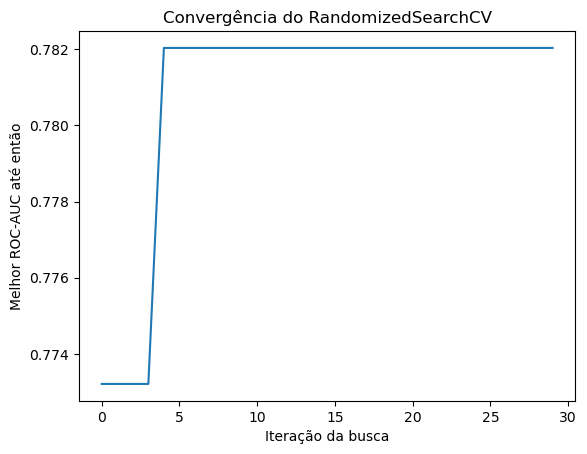

In [18]:
resultados = pd.DataFrame(random_search.cv_results_)
resultados['melhor_ate_agora'] = resultados['mean_test_score'].cummax()

resultados['melhor_ate_agora'].plot(
    xlabel='Iteração da busca',
    ylabel='Melhor ROC-AUC até então',
    title='Convergência do RandomizedSearchCV'
)

## 7. Produto final e priorização

### Avaliação final: o trade-off entre Precisão e Recall

No problema de crédito, dois tipos de erro são possíveis:
- **Falso Positivo (FP):** classificar um **bom** pagador como mau -> o banco recusa um cliente que pagaria certinho e perde a receita de juros dele.
- **Falso Negativo (FN):** classificar um **mau** pagador como bom -> o banco libera o crédito e sofre o calote.

O ideal seria um modelo com Precisão **e** Recall altos ao mesmo tempo para a classe "mau pagador": capturar a maioria dos maus pagadores (recall alto) sem recusar bons pagadores à toa (precisão alta). Isso é o que qualquer modelo de crédito busca, e é por isso que olhamos as duas métricas, e não só uma.

Só que, na prática, mexer no limiar de decisão (o ponto de corte da probabilidade estimada que separa "bom" de "mau") empurra as duas métricas em direções opostas: baixar o limiar classifica mais gente como "mau pagador" e pega mais maus pagadores de verdade (recall sobe), mas também classifica mais bons pagadores como maus por engano (precisão cai); subir o limiar faz o oposto. Salvo em casos raros de classes perfeitamente separáveis, **não existe um único limiar que maximize as duas métricas ao mesmo tempo** — isso é o trade-off entre Precisão e Recall.

### Qual lado do trade-off priorizar? Isso é uma decisão do banco

Não existe uma resposta estatística única para "qual erro é pior" — depende do apetite de risco e da estratégia comercial da instituição:

- Um banco **mais conservador**, focado em minimizar inadimplência, prefere errar recusando mais bons pagadores (mais FP) na troca por deixar passar menos maus pagadores (menos FN) — ou seja, prioriza o **Recall** da classe "mau pagador".
- Um banco **mais agressivo**, focado em crescer a carteira e a receita de juros, pode preferir aceitar mais risco de calote (mais FN) para recusar menos bons pagadores (menos FP) — prioriza a **Precisão** / a taxa de aprovação.

Abaixo, uso a matriz de custo oficial do German Credit Dataset como ponto de partida: ela assume que deixar passar um mau pagador custa **5 vezes mais** do que recusar um bom pagador por engano (proporção 5:1) — a mesma lógica 5:1 já usada lá atrás pra justificar o `class_weight='balanced'`. É a suposição do próprio dataset, mas vale deixar claro que é só uma hipótese de partida: um banco real, com outra política de risco, poderia usar uma proporção diferente (3:1, 10:1, ou até inverter a lógica se o produto de crédito fosse de baixo valor e alto volume). O código abaixo continua funcionando do mesmo jeito, bastando trocar os valores de `CUSTO_FN` e `CUSTO_FP` pela proporção que fizer sentido pro cenário do banco.

In [19]:
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]


In [20]:
# 1. Calcular a ROC-AUC no conjunto de teste (nao depende de limiar, pode ser direto)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC no Conjunto de Teste: {test_roc_auc:.4f}\n")

# 2. Escolher o limiar de decisao usando SOMENTE o treino (previsoes out-of-fold).
#    Antes, os limiares eram testados direto no y_test/y_pred_proba do teste, e o
#    escolhido (0.35) virava a avaliacao "final" nesse mesmo teste -> o teste
#    deixava de ser realmente nao visto (vazamento na escolha do limiar).
oof_proba_train = cross_val_predict(
    best_rf, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# Matriz de custo oficial do dataset German Credit: classificar um mau pagador
# como bom (Falso Negativo) custa 5x mais do que recusar um bom pagador por
# engano (Falso Positivo) - o mesmo racional 5:1 usado no class_weight.
CUSTO_FN = 5
CUSTO_FP = 1

thresholds = np.arange(0.05, 0.55, 0.05)
results = []
for thresh in thresholds:
    y_pred_thresh = (oof_proba_train >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_thresh).ravel()
    recall_mau = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_mau = tp / (tp + fp) if (tp + fp) > 0 else 0
    custo_total = CUSTO_FN * fn + CUSTO_FP * fp

    results.append({
        'Limiar': round(thresh, 2),
        'Recall (Maus Captados)': f"{recall_mau:.1%}",
        'Precisao': f"{precision_mau:.1%}",
        'FN (treino, OOF)': fn,
        'FP (treino, OOF)': fp,
        'Custo Total (5xFN + 1xFP)': custo_total
    })

df_thresholds = pd.DataFrame(results)
print("--- Varredura de limiares no TREINO (previsoes out-of-fold) ---")
print(df_thresholds.to_string(index=False))

limiar_otimizado = float(thresholds[df_thresholds['Custo Total (5xFN + 1xFP)'].idxmin()])
print(f"\nLimiar que minimiza o custo esperado (5:1): {limiar_otimizado:.2f}")


ROC-AUC no Conjunto de Teste: 0.7790

--- Varredura de limiares no TREINO (previsoes out-of-fold) ---
 Limiar Recall (Maus Captados) Precisao  FN (treino, OOF)  FP (treino, OOF)  Custo Total (5xFN + 1xFP)
   0.05                 100.0%    30.0%                 0               560                        560
   0.10                 100.0%    30.0%                 0               560                        560
   0.15                 100.0%    30.0%                 0               560                        560
   0.20                 100.0%    30.1%                 0               558                        558
   0.25                 100.0%    30.8%                 0               540                        540
   0.30                  99.2%    32.5%                 2               494                        504
   0.35                  97.9%    35.9%                 5               420                        445
   0.40                  94.6%    40.6%                13               33

Com o limiar escolhido usando somente as previsões *out-of-fold* do treino (célula acima), aplicamos esse valor **uma única vez** no conjunto de teste — que segue intocado até aqui — e comparamos com o limiar padrão (0.50) pra deixar claro o efeito prático dessa escolha.

RELATORIO DE CLASSIFICACAO - LIMIAR PADRAO (0.5)
                 precision    recall  f1-score   support

Bom Pagador (0)       0.85      0.67      0.75       140
Mau Pagador (1)       0.48      0.72      0.58        60

       accuracy                           0.69       200
      macro avg       0.66      0.69      0.66       200
   weighted avg       0.74      0.69      0.70       200

RELATORIO DE CLASSIFICACAO - LIMIAR OTIMIZADO (0.40)
                 precision    recall  f1-score   support

Bom Pagador (0)       0.93      0.37      0.53       140
Mau Pagador (1)       0.39      0.93      0.55        60

       accuracy                           0.54       200
      macro avg       0.66      0.65      0.54       200
   weighted avg       0.77      0.54      0.54       200



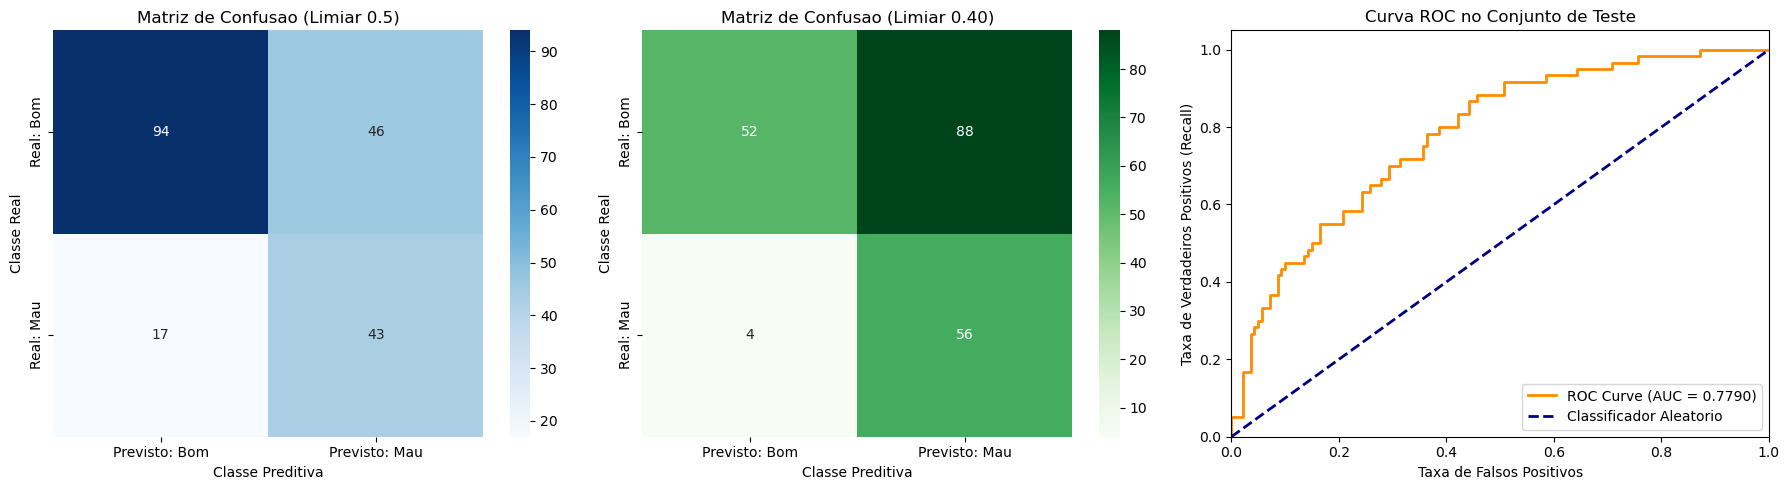


RESUMO DE DECISAO FINANCEIRA - MODELO FINAL (LIMIAR 0.40)
- Total de Clientes na Base de Teste: 200
- Bons Pagadores Aprovados (TN): 52
- Bons Pagadores Recusados por Cautela (FP): 88
- Maus Pagadores Identificados e Bloqueados (TP): 56 de 60 (93.3%)
- Calotes Liberados / Falsos Negativos (FN): 4


In [21]:
limiar_padrao = 0.50

y_pred_050 = (y_pred_proba >= limiar_padrao).astype(int)
y_pred_otimizado = (y_pred_proba >= limiar_otimizado).astype(int)

# 2. Exibir os Relatorios de Classificacao no Terminal
print("=" * 65)
print(f"RELATORIO DE CLASSIFICACAO - LIMIAR PADRAO ({limiar_padrao})")
print("=" * 65)
print(classification_report(y_test, y_pred_050, target_names=['Bom Pagador (0)', 'Mau Pagador (1)']))

print("=" * 65)
print(f"RELATORIO DE CLASSIFICACAO - LIMIAR OTIMIZADO ({limiar_otimizado:.2f})")
print("=" * 65)
print(classification_report(y_test, y_pred_otimizado, target_names=['Bom Pagador (0)', 'Mau Pagador (1)']))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Matriz de Confusao (Limiar 0.50)
cm_050 = confusion_matrix(y_test, y_pred_050)
sns.heatmap(
    cm_050,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Previsto: Bom', 'Previsto: Mau'],
    yticklabels=['Real: Bom', 'Real: Mau']
)
axes[0].set_title(f'Matriz de Confusao (Limiar {limiar_padrao})')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Preditiva')

# Subplot 2: Matriz de Confusao (Limiar otimizado)
cm_otimizado = confusion_matrix(y_test, y_pred_otimizado)
sns.heatmap(
    cm_otimizado,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1],
    xticklabels=['Previsto: Bom', 'Previsto: Mau'],
    yticklabels=['Real: Bom', 'Real: Mau']
)
axes[1].set_title(f'Matriz de Confusao (Limiar {limiar_otimizado:.2f})')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Preditiva')

# Subplot 3: Curva ROC no Teste
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatorio')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Taxa de Falsos Positivos')
axes[2].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[2].set_title('Curva ROC no Conjunto de Teste')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 4. Resumo numerico detalhado do impacto de credito
tn_o, fp_o, fn_o, tp_o = cm_otimizado.ravel()
print("\n" + "=" * 65)
print(f"RESUMO DE DECISAO FINANCEIRA - MODELO FINAL (LIMIAR {limiar_otimizado:.2f})")
print("=" * 65)
print(f"- Total de Clientes na Base de Teste: {len(y_test)}")
print(f"- Bons Pagadores Aprovados (TN): {tn_o}")
print(f"- Bons Pagadores Recusados por Cautela (FP): {fp_o}")
print(f"- Maus Pagadores Identificados e Bloqueados (TP): {tp_o} de {tp_o + fn_o} ({tp_o / (tp_o + fn_o):.1%})")
print(f"- Calotes Liberados / Falsos Negativos (FN): {fn_o}")
print("=" * 65)


* Trade-off de Conservadorismo e Custo de Oportunidade: A maior rigidez no limiar de 0.40 elevou os falsos positivos de 46 para 88. Isso derrubou o Recall dos bons pagadores para 37% (apenas 52 aprovados de 140), resultando em alto custo de oportunidade devido à rejeição cautelar de clientes adimplentes.
* Queda na Precisão do Alerta de Risco: Com o limiar em 0.40, a Precision para maus pagadores caiu para 39% (contra 48% no limiar 0.50), indicando que 61% dos clientes sinalizados como de risco no novo corte seriam, na verdade, bons pagadores.
* Alinhamento Estratégico: A escolha do limiar 0.40 reflete uma postura de crédito avessa ao risco, onde o custo unitário do calote (inadimplência) é considerado substancialmente superior à margem de lucro perdida ao negar crédito a um bom pagador.

Recall Score (0.93 / 93%): O Recall (métrica principal desta análise), também conhecido como taxa de verdadeiros positivos ou sensibilidade, mede a proporção de casos positivos reais (clientes de mau risco) que o modelo identifica corretamente. No limiar otimizado de 0.40, o modelo identifica corretamente 93,3% dos clientes de mau risco. Na prática, observando a matriz de confusão, isso significa que ele classificou corretamente 56 de 60 clientes maus pagadores, deixando passar apenas 4 calotes (falsos negativos).

Precision Score (0.39 / 39%): A precisão quantifica a proporção de casos previstos como positivo (mau risco) que realmente eram maus pagadores. De todos os clientes apontados como alto risco pelo modelo, 39% pertencem de fato a essa classe. Na prática, pela matriz de confusão, das 144 pessoas sinalizadas como mau risco (56 verdadeiros positivos + 88 falsos positivos), 56 eram realmente maus pagadores. Embora a precisão seja mais baixa, classificar temporariamente bons clientes como mau risco (falsos positivos) gera um custo de oportunidade que o banco aceita assumir em troca de evitar o prejuízo direto dos calotes.

AUC Score (0.78 / 77,9%): O AUC Score (Área Sob a Curva ROC) representa o desempenho global do modelo em separar as classes de bom e mau risco, independentemente do ponto de corte escolhido. Ele mede a probabilidade de o modelo ranquear um cliente inadimplente escolhido ao acaso com um risco maior do que um cliente bom pagador. Com uma AUC de 0.7790, o modelo demonstra uma boa capacidade de discriminação e separação entre os perfis de crédito.

### Interpretando os resultados com a importância das variáveis

Depois de escolher o limiar de decisão, vale entender **quais variáveis o modelo está usando mais** para separar bons de maus pagadores — ajuda a checar se os resultados fazem sentido do ponto de vista de negócio (não só estatisticamente) 

O Random Forest calcula a importância de cada variável olhando o quanto ela reduz a impureza (Gini) em média, toda vez que é usada pra dividir os dados, somado ao longo de todas as árvores da floresta.


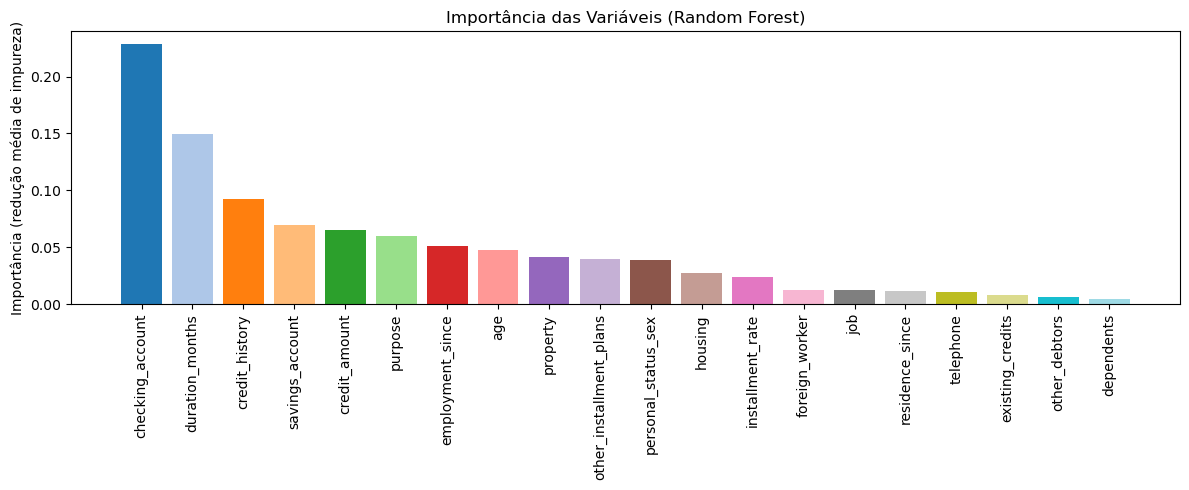

variavel
checking_account           0.228286
duration_months            0.149494
credit_history             0.092253
savings_account            0.069149
credit_amount              0.065310
purpose                    0.059543
employment_since           0.051453
age                        0.047459
property                   0.041371
other_installment_plans    0.040071
personal_status_sex        0.038838
housing                    0.027118
installment_rate           0.023576
foreign_worker             0.012520
job                        0.012196
residence_since            0.011912
telephone                  0.010316
existing_credits           0.008145
other_debtors              0.006186
dependents                 0.004805
Name: importancia, dtype: float64

In [22]:
# Usa o pipeline final (preprocessor + RandomForest tunado) pra calcular e plotar
importancias_finais = plotar_importancia_variaveis(best_rf)
importancias_finais


status da conta corrente é a feature mais significante para a previsão, seguido de tempo do emprestimo, histórico de empresitmo. Essa relação bate com as conclusões do notebook de EDA, alem dessas top 3 features, estão valor do empresitmo, proposito do emprestimo, e conta poupança tambem estavam nas conclusões do EDA. Ou seja o modelo está consistente e aceitável em relação as nossa hipóteses anteriores

## 8.Conclusões

* Neste projeto, desenvolvemos e avaliamos modelos de aprendizado de máquina para prever o risco de crédito em clientes do German Credit Dataset. O objetivo principal foi construir um estimador capaz de discriminar eficientemente entre bons e maus pagadores, utilizando o ROC-AUC como métrica central de otimização durante a validação cruzada e o tuning de hiperparâmetros. Dessa forma, a instituição financeira obtém subsídios para tomar decisões mais assertivas, equilibrando a rentabilidade com uma gestão de risco prudente.
*  Tratamento de Dados e Prevenção de Data Leakage: Para lidar com o desbalanceamento das classes e garantir a integridade dos resultados, aplicamos validação cruzada estratificada (Stratified K-Fold) integrada a um Pipeline, garantindo que o pré-processamento (encoding e escalonamento) fosse reajustado em cada fold, sem contato com os dados de validação.
* Comparação de Modelos e Tuning de Hiperparâmetros: Avaliamos o desempenho baseline da Regressão Logística e do Random Forest. A Regressão Logística atingiu o maior score médio inicial de ROC-AUC , enquanto o Random Forest alcançou uma nota um pouco menor. Escolhemos o Random Forest para a etapa de ajuste fino via RandomizedSearchCV (scoring='roc_auc') para controlar o overfitting e capturar relações não lineares entre as variáveis.
* Interpretação e Relevância dos Atributos: A análise das variáveis mais importantes (feature importances) do modelo final confirmou os padrões identificados durante a etapa de EDA. Variáveis como histórico de crédito, duração do empréstimo e saldo da conta corrente demonstraram forte poder preditivo, garantindo coerência técnica e alinhamento com a lógica de negócio.
*A escolha do Random Forest para a etapa de otimização de hiperparâmetros baseou-se na hipótese de que o forte overfitting do modelo baseline (1,00 no treino vs. 0,7721 na validação) cobria um potencial preditivo ainda não explorado. Metodologicamente, a aposta provou-se correta no controle de variância: a distância entre o desempenho no treino e na validação foi drasticamente reduzida de ~0,23 para 0,077, resultando em um modelo substancialmente mais estável e generalizável. No entanto, a métrica no conjunto de validação apresentou um ganho marginal (atingindo 0,7820), mantendo-se no mesmo patamar da Regressão Logística (0,7760). Esse comportamento indica que a eliminação da memorização não se desdobrou em um aumento relevante do poder discriminatório. Em suma, o ajuste comprovou que a limitação em torno de ~0,78 reflete um teto inerente à informação contida nos dados e no conjunto atual de features, e não uma sub-otimização do algoritmo. A decisão de tunar o Random Forest garantiu a entrega de um modelo robusto para produção, ao mesmo tempo em que sinalizou que novos ganhos de performance dependerão prioritariamente de engenharia de atributos ou novas fontes de dados, e não do ajuste de algoritmos.